# 2D k-Nearest Neighbors Classification from Scratch

Let's build a k-NN classifier manually to better understand how it makes predictions.

We'll:
1. Generate synthetic 2D data for two classes
2. Implement the k-NN classifier
3. Visualize decision boundaries using different $k$ values
4. Find the optimal $k$

Let's start with some synthetic data, creating two classes (labeled as 0 and 1) with some overlapping data:

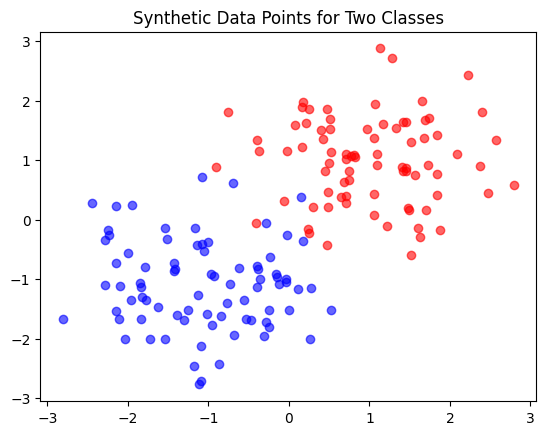

((160, 2), (160,))

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2025)
x_0 = np.random.normal(loc=-1, scale=0.8, size=(80,2))
y_0 = np.zeros(80, dtype=int)
x_1 = np.random.normal(loc=1, scale=0.8, size=(80,2))
y_1 = np.ones(80, dtype=int)

# Plot the data points
plt.scatter(x_0[:,0], x_0[:,1], color='blue', label='Class 0', alpha=0.6)
plt.scatter(x_1[:,0], x_1[:,1], color='red', label='Class 1', alpha=0.6)
plt.title('Synthetic Data Points for Two Classes')
plt.show()

x_train = np.vstack((x_0, x_1))
y_train = np.concatenate([y_0, y_1])

x_train.shape, y_train.shape

The k-NN classification algorithm works in four main steps for a given prediction:

1.  **Distance:** Calculate the distance between the query point and all training points
2.  **Sort:** Sort the training points by distance to find the closest ones
3.  **Select:** Select the top $k$ nearest neighbors
4.  **Vote:** Determine the class label by majority vote among the neighbors, with ties going to the lower value

In [2]:
def knn_classify(x_train, y_train, x_query, k):
    y_query = []
    for x in x_query:
        # 1. Distance
        distance = np.linalg.norm(x_train - x, axis=1)

        # 2. Sort
        sorted_indices = np.argsort(distance)

        # 3. Select
        k_indices = sorted_indices[:k]

        # 4. Vote
        k_nearest_labels = y_train[k_indices]
        counts = np.bincount(k_nearest_labels)
        predicted_label = np.argmax(counts)

        y_query.append(predicted_label)
    return np.array(y_query)

Let's see the boundary created by the classifier with different $k$ values. We'll generate a grid of points and classify each one to see the regions assigned to each class.

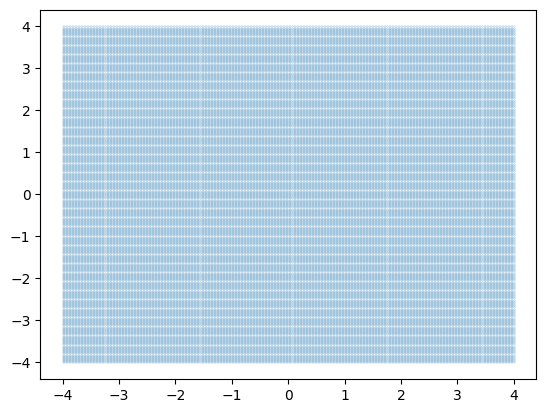

In [3]:
# Make 2D grid array -4 to 4
x = np.linspace(-4, 4, 300)
y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.ravel(), Y.ravel()]).T

# Plot
plt.scatter(X, Y, s=.01)
plt.show()

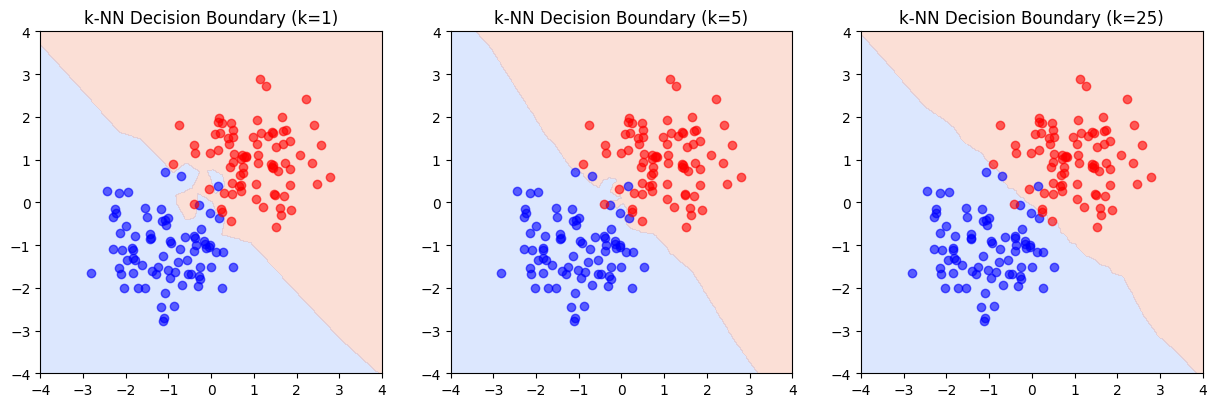

In [4]:
k1_preds = knn_classify(x_train, y_train, points, k=1)
k5_preds = knn_classify(x_train, y_train, points, k=5)
k25_preds = knn_classify(x_train, y_train, points, k=25)

# Plot decision boundaries
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, preds, k in zip(axs, [k1_preds, k5_preds, k25_preds], [1, 5, 25]):
    Z = np.array(preds).reshape(X.shape)
    ax.contourf(X, Y, Z, alpha=0.3, levels=np.arange(-0.5, 2), cmap='coolwarm')
    ax.scatter(x_0[:,0], x_0[:,1], color='blue', label='Class 0', alpha=0.6)
    ax.scatter(x_1[:,0], x_1[:,1], color='red', label='Class 1', alpha=0.6)
    ax.set_title(f'k-NN Decision Boundary (k={k})')
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal', 'box')
plt.show()

*   **Low $k$:** The boundary is jagged and captures local noise. This is overfitting.
*   **High $k$:** The boundary becomes smoother and approaches a linear separator. This can underfit.

To find the optimal $k$, we can split our data into training and testing sets and calculate the accuracy of predictions on the test set for various $k$ values. With evenly-sized classes and no desire to avoid type 1 or 2 errors, we don't need to worry about precision/recall for now.

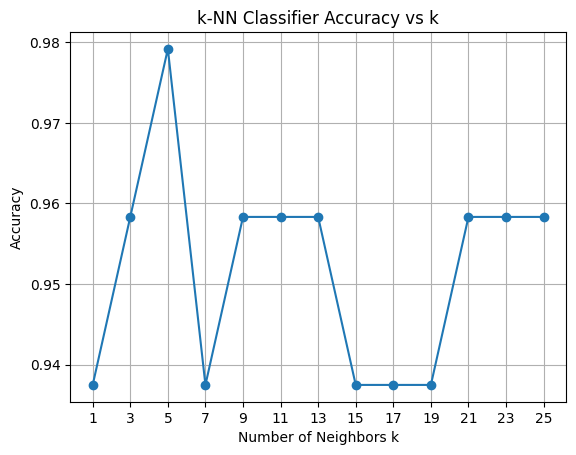

In [7]:
# Split into train and test sets and find optimal k
from sklearn.model_selection import train_test_split
x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(
    x_train, y_train, test_size=0.3, random_state=2025)
ks = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
accuracies = []
for k in ks:
    y_test_preds = knn_classify(x_train_split, y_train_split, x_test_split, k)
    accuracy = np.mean(y_test_preds == y_test_split)
    accuracies.append(accuracy)

# Plot accuracies
plt.plot(ks, accuracies, marker='o')
plt.title('k-NN Classifier Accuracy vs k')
plt.xlabel('Number of Neighbors k')
plt.ylabel('Accuracy')
plt.xticks(ks)
plt.grid()
plt.show()

So what did we learn?

1.  **Low $k$ Overfits:** With $k=1$, the decision boundary is very complex and sensitive to individual data points.
2.  **High $k$ Underfits:** Increasing $k$ smooths the boundary. If $k$ is too large, it may ignore relevant local structure.
3.  **Maximize Accuracy to Find Optimal $k$:** By iterating over a range of $k$ values and plotting the accuracy on a hold-out test set, we can identify the $k$ that generalizes best.